In [9]:
from Optimizers import *
from LearningRateCallbacks import *
from Terrains import *

import matplotlib.pyplot as plt

In [10]:
np.random.seed(42)

In [11]:
def plot_convergence_results(optimizer_1, optimizer_2,
                             optimizer_1_name='Adam convergence',
                             optimizer_2_name='2nd-degree optimizer convergence'):
    plt.figure(figsize=(10, 6))

    hist1 = optimizer_1.track_history()['convergence_history']
    hist2 = optimizer_2.track_history()['convergence_history']

    plt.semilogy(hist1, label=optimizer_1_name)
    plt.semilogy(hist2, label=optimizer_2_name)

    plt.xlabel('Iteration')
    plt.ylabel('Distance to minimum (log scale)')
    plt.legend()
    plt.title('Convergence Comparison')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_lr_history(optimizer):
    plt.figure(figsize=(10, 4))
    plt.semilogy(optimizer.track_history()['lr_history'])
    plt.xlabel('Iteration')
    plt.ylabel('Learning Rate (log scale)')
    plt.title('Learning Rate History')
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
import time

def clock_experiments(against_optimizer, optimizer_2, against_opt_name, opt_2_name, steps=1000):
  start_time_against_optimizer = time.perf_counter()
  for _ in range(steps):
    against_optimizer.step()
  end_time_against_optimizer = time.perf_counter()

  elapsed_time_against_optimizer =  end_time_against_optimizer - start_time_against_optimizer

  start_time = time.perf_counter()
  for _ in range(steps):
    optimizer_2.step()
  end_time = time.perf_counter()

  elapsed_time = end_time - start_time


  plot_convergence_results(against_optimizer, optimizer_2, optimizer_1_name=against_opt_name, optimizer_2_name=opt_2_name)
  plot_lr_history(optimizer_2)

  print("="*40)
  print(f"Adam final distance: {against_optimizer.track_history()['convergence_history'][-1]:.2e}")
  print(f"Our optimizer final distance: {optimizer_2.track_history()['convergence_history'][-1]:.2e}")
  print("="*40)
  print(f"Time Taken for {against_opt_name} : {elapsed_time_against_optimizer:.4f}")
  print(f"Time Taken for {opt_2_name} : {elapsed_time:.4f}")

# Version Tests

In [13]:
import numpy as np


class CurvatureAndGradientBasedOptimizer_v1:

    def __init__(
            self,
            function_to_optimize,
            starting_point,
            minimum_learning_rate,
            maximum_learning_rate,
            alpha,
            beta
    ):
        self.fn = function_to_optimize
        self.min_lr = minimum_learning_rate
        self.max_lr = maximum_learning_rate
        self.alpha = alpha
        self.beta = beta
        self.t = 0
        self.x = np.array(starting_point, dtype=float)
        self.g = np.zeros_like(self.x)
        self.g_bar = np.zeros_like(self.x)
        self.g_hat = np.zeros_like(self.x)
        self.kappa_bar = 0.0
        self.kappa_hat = 0.0

        self.history_x = []
        self.history_g_hat = []
        self.history_kappa_hat = []
        self.history_lr = []
        self.history_euclidean_distance_minima_convergence = []

    def calculate_gradients(self):
        return self.fn.gradients(self.x)

    def calculate_hessian_change(self, epsilon=1e-4):
        return (self.fn.gradients(self.x + epsilon * self.g) - self.g) / epsilon

    def calculate_curvature(self):
        denominator = self.g.T @ self.g
        if denominator < 1e-12:
            return 0.0
        return (self.g.T @ self.calculate_hessian_change()) / denominator

    def track_curvature_and_gradient(self):
        self.t += 1
        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * self.g
        kappa = self.calculate_curvature()
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * kappa
        self.g_hat = self.g_bar / (1 - self.alpha ** self.t)
        self.kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        return self.kappa_hat, self.g_hat

    def get_learning_rate(self):
        grad_norm = np.linalg.norm(self.g_hat)
        abs_kappa = np.abs(self.kappa_hat)

        kappa_high_threshold = 1.0
        grad_high_threshold = 1.0

        kappa_high = abs_kappa > kappa_high_threshold
        grad_high = grad_norm > grad_high_threshold
        kappa_positive = self.kappa_hat > 0

        if (kappa_positive and kappa_high) or (not kappa_positive and kappa_high and grad_high):
            eta = 0.001
        else:
            eta = 0.1

        return float(np.clip(eta, self.min_lr, self.max_lr))

    def step(self):
        self.g = self.calculate_gradients()
        kappa_hat, g_hat = self.track_curvature_and_gradient()
        eta = self.get_learning_rate()
        self.x = self.x - eta * g_hat

        self.history_x.append(self.x.copy())
        self.history_g_hat.append(g_hat.copy())
        self.history_kappa_hat.append(kappa_hat)
        self.history_lr.append(eta)

        minima = self.fn.minima()
        if minima is not None:
            self.history_euclidean_distance_minima_convergence.append(
                np.linalg.norm(self.x - minima)
            )

        return self.x, eta, kappa_hat, g_hat

    def track_history(self):
        return {
            "x_history": self.history_x,
            "g_hat_history": self.history_g_hat,
            "kappa_hat_history": self.history_kappa_hat,
            "lr_history": self.history_lr,
            "convergence_history": self.history_euclidean_distance_minima_convergence
        }

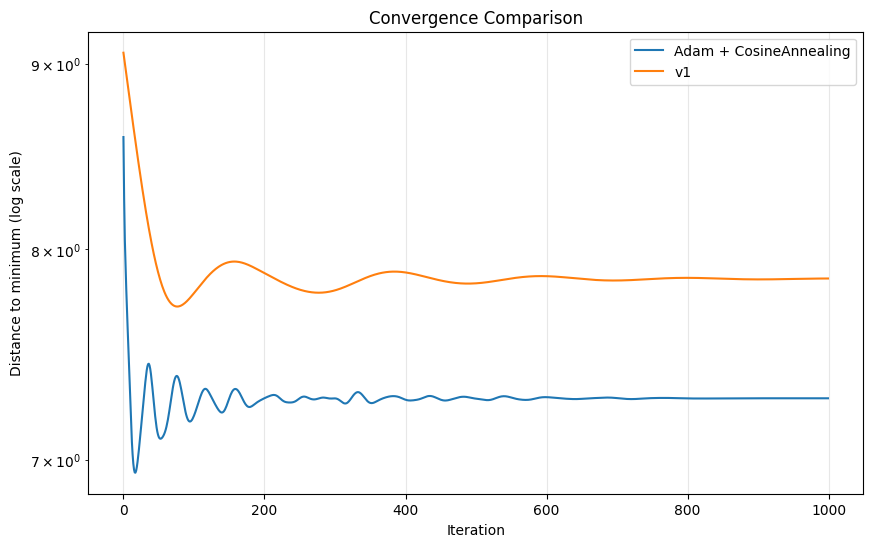

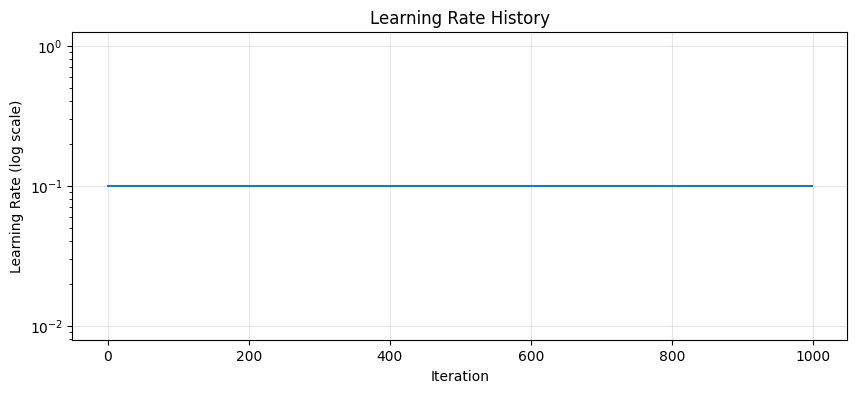

Adam final distance: 7.28e+00
Our optimizer final distance: 7.85e+00
Time Taken for Adam + CosineAnnealing : 0.6922
Time Taken for v1 : 0.8685


In [14]:
x0 = np.random.randn(100)
terrain = AckleyND(100)

v1 = CurvatureAndGradientBasedOptimizer_v1(
    function_to_optimize=terrain,
    starting_point=x0,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    alpha=0.99,
    beta=0.999
)

callback = CosineAnnealing(
    base_learning_rate=1e-1,
    minimum_learning_rate=1e-5,
    total_steps=1000
)

against_optimizer = Adam(
    function_to_optimize=terrain,
    beta=0.99,
    alpha=0.999,
    x=x0.copy(),
    epsilon=1e-8,
    scheduler=callback
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v1,
                  against_opt_name="Adam + CosineAnnealing",
                  opt_2_name='v1')

In [15]:
import numpy as np


class CurvatureAndGradientBasedOptimizer_v2:

    def __init__(
            self,
            function_to_optimize,
            starting_point,
            minimum_learning_rate,
            maximum_learning_rate,
            alpha,
            beta
    ):
        self.fn = function_to_optimize
        self.min_lr = minimum_learning_rate
        self.max_lr = maximum_learning_rate
        self.alpha = alpha
        self.beta = beta
        self.t = 0
        self.x = np.array(starting_point, dtype=float)
        self.g = np.zeros_like(self.x)
        self.g_bar = np.zeros_like(self.x)
        self.g_hat = np.zeros_like(self.x)
        self.kappa_bar = 0.0
        self.kappa_hat = 0.0

        self.history_x = []
        self.history_g_hat = []
        self.history_kappa_hat = []
        self.history_lr = []
        self.history_euclidean_distance_minima_convergence = []

    def calculate_gradients(self):
        return self.fn.gradients(self.x)

    def calculate_hessian_change(self, epsilon=1e-4):
        raw = (self.fn.gradients(self.x + epsilon * self.g) - self.g) / epsilon
        return raw/np.linalg.norm(self.g)

    def calculate_curvature(self):
        g_norm = self.g/np.linalg.norm(self.g)
        denominator = g_norm.T @ g_norm
        return (g_norm.T @ self.calculate_hessian_change()) / denominator

    def track_curvature_and_gradient(self):
        self.t += 1
        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * self.g
        kappa = self.calculate_curvature()
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * kappa ** 2
        self.g_hat = self.g_bar / (1 - self.alpha ** self.t)
        self.kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        return self.kappa_hat, self.g_hat

    def relu(self, x):
        return np.where(x > 0, x, 0)
    def revrelu(self, x):
        return np.where(x < 0, -x, 0)
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def get_learning_rate(self):
        g_distance = np.linalg.norm(self.g_hat)
        term_1 = 1 / (self.relu(self.kappa_hat) + 1 / g_distance)
        term_2 = (1 - self.sigmoid(self.revrelu(self.kappa_hat * g_distance)))
        lr = (term_1 + term_2)
        return float(np.clip(lr, self.min_lr, self.max_lr))

    def step(self):
        self.g = self.calculate_gradients()
        kappa_hat, g_hat = self.track_curvature_and_gradient()
        eta = self.get_learning_rate()
        self.x = self.x - eta * g_hat / kappa_hat

        self.history_x.append(self.x.copy())
        self.history_g_hat.append(g_hat.copy())
        self.history_kappa_hat.append(kappa_hat)
        self.history_lr.append(eta)

        minima = self.fn.minima()
        if minima is not None:
            self.history_euclidean_distance_minima_convergence.append(
                np.linalg.norm(self.x - minima)
            )

        return self.x, eta, kappa_hat, g_hat

    def track_history(self):
        return {
            "x_history": self.history_x,
            "g_hat_history": self.history_g_hat,
            "kappa_hat_history": self.history_kappa_hat,
            "lr_history": self.history_lr,
            "convergence_history": self.history_euclidean_distance_minima_convergence
        }

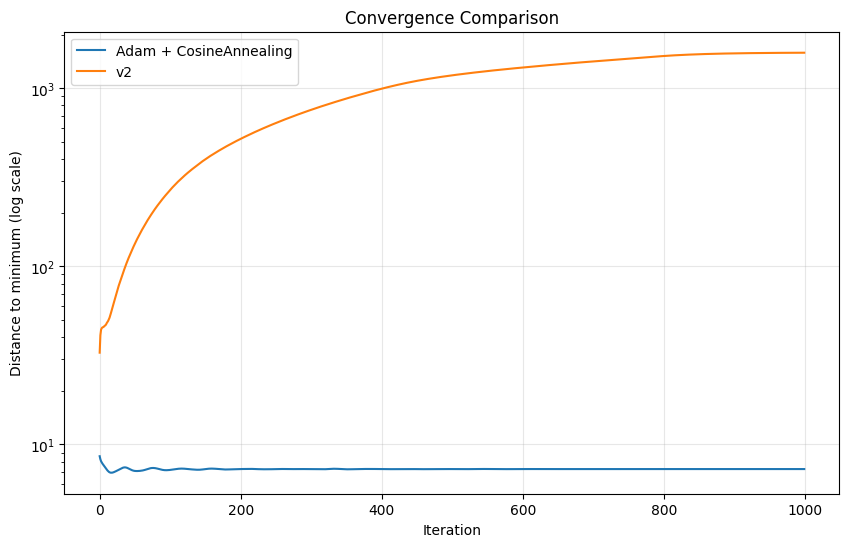

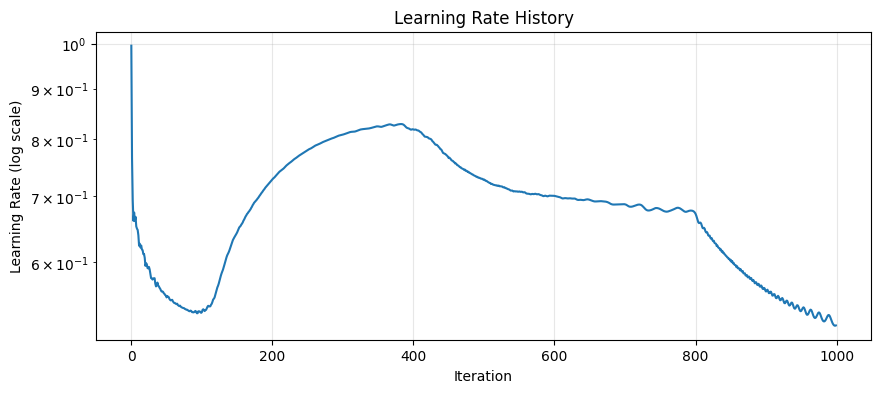

Adam final distance: 7.28e+00
Our optimizer final distance: 1.58e+03
Time Taken for Adam + CosineAnnealing : 0.5339
Time Taken for v2 : 0.8752


In [16]:
v2 = CurvatureAndGradientBasedOptimizer_v2(
    function_to_optimize=terrain,
    starting_point=x0,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = CosineAnnealing(
    base_learning_rate=1e-1,
    minimum_learning_rate=1e-5,
    total_steps=1000
)

against_optimizer = Adam(
    function_to_optimize=terrain,
    beta=0.99,
    alpha=0.999,
    x=x0.copy(),
    epsilon=1e-8,
    scheduler=callback
)


clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v2,
                  against_opt_name="Adam + CosineAnnealing",
                  opt_2_name='v2')

In [17]:
import numpy as np


class CurvatureAndGradientBasedOptimizer_v3:

    def __init__(
            self,
            function_to_optimize,
            starting_point,
            minimum_learning_rate,
            maximum_learning_rate,
            alpha,
            beta
    ):
        self.fn = function_to_optimize
        self.min_lr = minimum_learning_rate
        self.max_lr = maximum_learning_rate
        self.alpha = alpha
        self.beta = beta
        self.t = 0
        self.x = np.array(starting_point, dtype=float)
        self.g = np.zeros_like(self.x)
        self.g_bar = np.zeros_like(self.x)
        self.g_hat = np.zeros_like(self.x)
        self.kappa_bar = 0.0
        self.kappa_hat = 0.0

        self.history_x = []
        self.history_g_hat = []
        self.history_kappa_hat = []
        self.history_lr = []
        self.history_euclidean_distance_minima_convergence = []

    def calculate_gradients(self):
        return self.fn.gradients(self.x)

    def calculate_hessian_change(self, epsilon=1e-4):
        raw = (self.fn.gradients(self.x + epsilon * self.g) - self.g) / epsilon
        return raw/np.linalg.norm(self.g)

    def calculate_curvature(self):
        g_norm = self.g/np.linalg.norm(self.g)
        denominator = g_norm.T @ g_norm
        return (g_norm.T @ self.calculate_hessian_change()) / denominator

    def track_curvature_and_gradient(self):
        self.t += 1
        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * self.g
        kappa = self.calculate_curvature()
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * kappa ** 2
        self.g_hat = self.g_bar / (1 - self.alpha ** self.t)
        self.kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        return self.kappa_hat, self.g_hat

    def relu(self, x):
        return np.where(x > 0, x, 0)
    def revrelu(self, x):
        return np.where(x < 0, -x, 0)
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def get_learning_rate(self):
        g_distance = np.linalg.norm(self.g_hat)
        term_1 = 1 / (self.relu(self.kappa_hat) + 1 / g_distance)
        term_2 = (self.sigmoid(self.revrelu(self.kappa_hat * g_distance)))
        lr = (term_1 + term_2)
        return float(np.clip(lr, self.min_lr, self.max_lr))

    def step(self):
        self.g = self.calculate_gradients()
        kappa_hat, g_hat = self.track_curvature_and_gradient()
        eta = self.get_learning_rate()
        self.x = self.x - eta * g_hat / np.sqrt(kappa_hat)

        self.history_x.append(self.x.copy())
        self.history_g_hat.append(g_hat.copy())
        self.history_kappa_hat.append(kappa_hat)
        self.history_lr.append(eta)

        minima = self.fn.minima()
        if minima is not None:
            self.history_euclidean_distance_minima_convergence.append(
                np.linalg.norm(self.x - minima)
            )

        return self.x, eta, kappa_hat, g_hat

    def track_history(self):
        return {
            "x_history": self.history_x,
            "g_hat_history": self.history_g_hat,
            "kappa_hat_history": self.history_kappa_hat,
            "lr_history": self.history_lr,
            "convergence_history": self.history_euclidean_distance_minima_convergence
        }

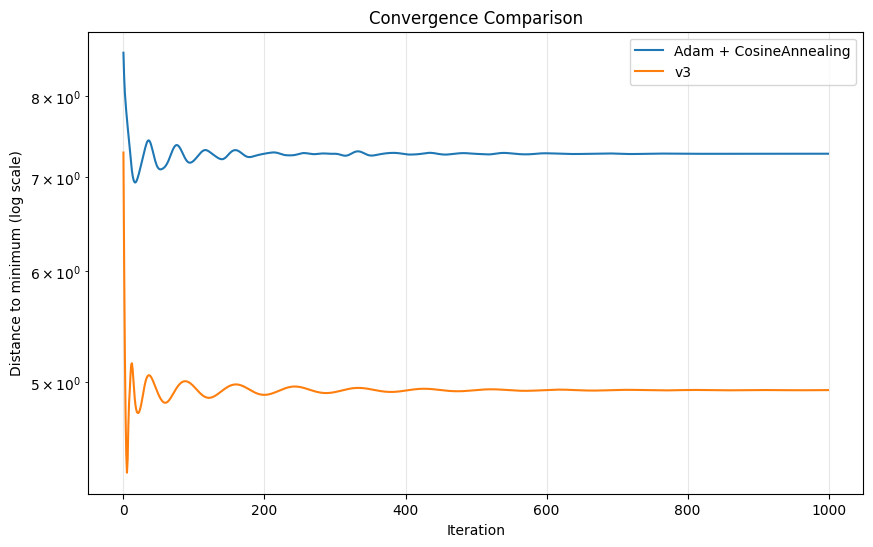

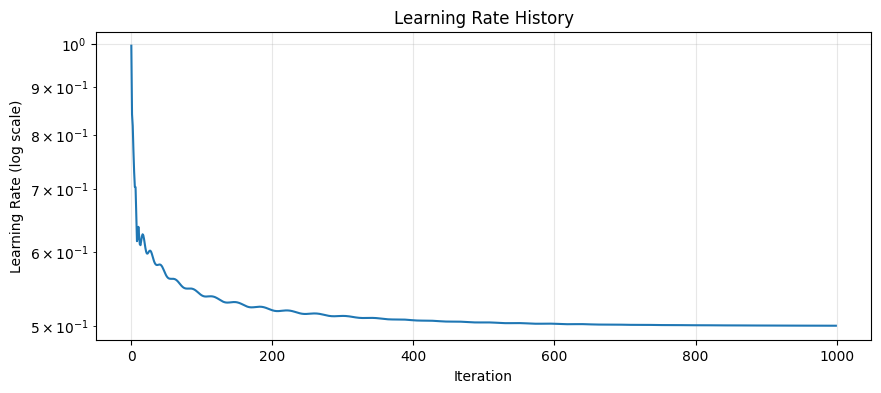

Adam final distance: 7.28e+00
Our optimizer final distance: 4.94e+00
Time Taken for Adam + CosineAnnealing : 0.4805
Time Taken for v3 : 0.8826


In [18]:
v3 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x0,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = CosineAnnealing(
    base_learning_rate=1e-1,
    minimum_learning_rate=1e-5,
    total_steps=1000
)

against_optimizer = Adam(
    function_to_optimize=terrain,
    beta=0.99,
    alpha=0.999,
    x=x0.copy(),
    epsilon=1e-8,
    scheduler=callback
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3,
                  against_opt_name="Adam + CosineAnnealing",
                  opt_2_name='v3')

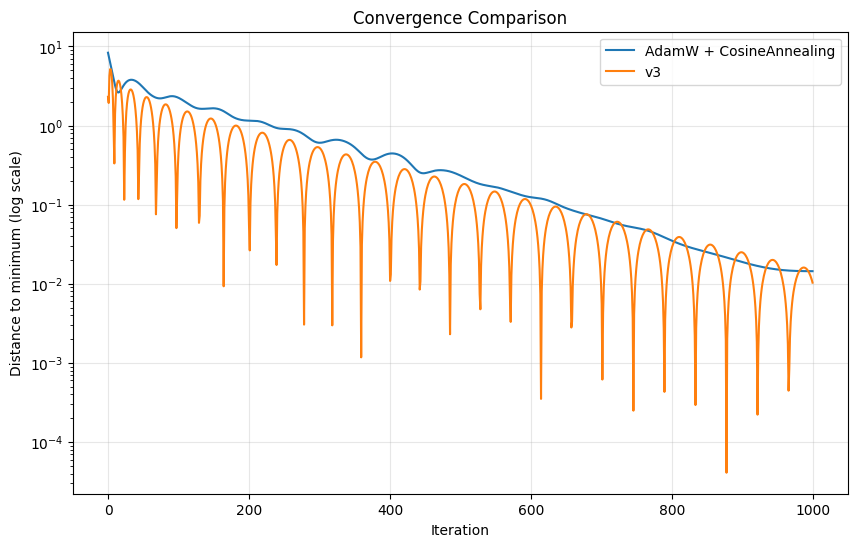

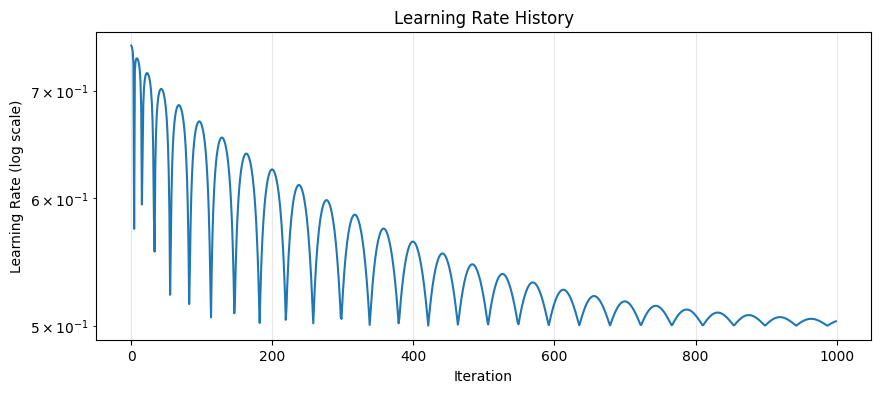

Adam final distance: 1.44e-02
Our optimizer final distance: 1.03e-02
Time Taken for AdamW + CosineAnnealing : 0.2330
Time Taken for v3 : 0.4801


In [19]:
terrain = Sphere(100)

v3_2 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x0,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = CosineAnnealing(
    base_learning_rate=1e-1,
    minimum_learning_rate=1e-5,
    total_steps=1000
)

against_optimizer = AdamW(
    function_to_optimize=terrain,
    beta=0.99,
    alpha=0.999,
    x=x0.copy(),
    epsilon=1e-8,
    scheduler=callback,
    regularization_factor = 0.01
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_2,
                  against_opt_name="AdamW + CosineAnnealing",
                  opt_2_name='v3')

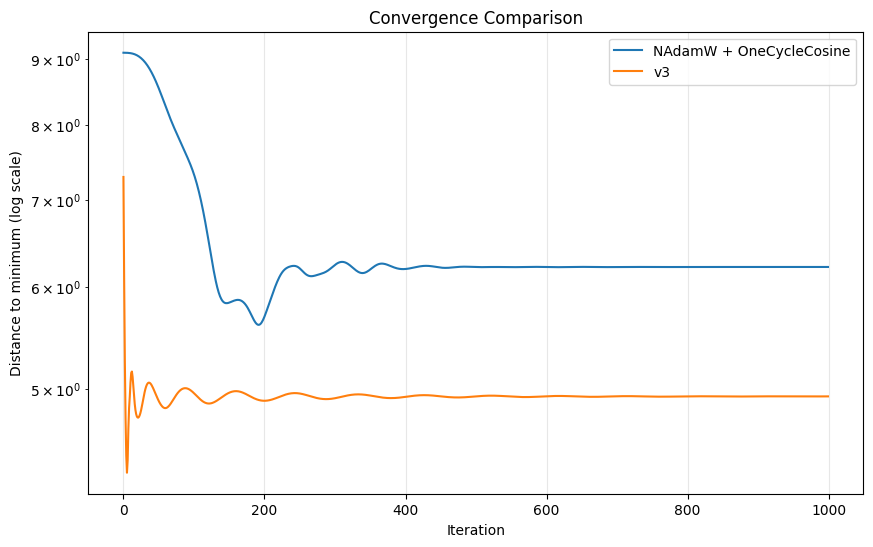

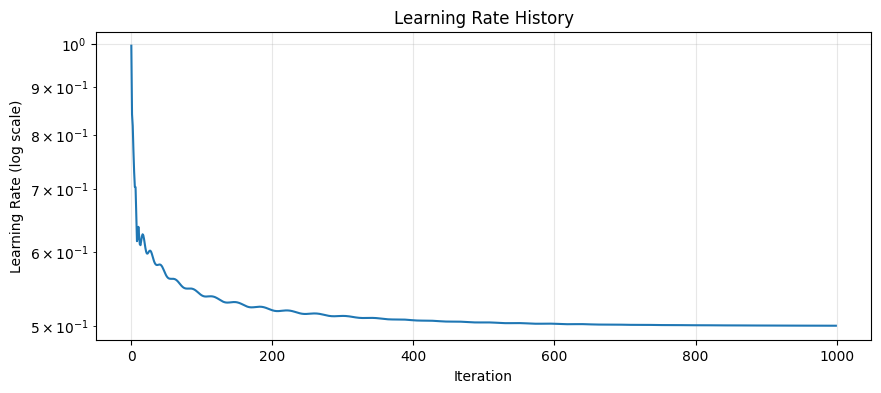

Adam final distance: 6.21e+00
Our optimizer final distance: 4.94e+00
Time Taken for NAdamW + OneCycleCosine : 0.6869
Time Taken for v3 : 1.3682


In [20]:
terrain = AckleyND(100)

v3_3 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x0,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = NAdamW(
    function_to_optimize=terrain,
    beta=0.99,
    alpha=0.999,
    x=x0.copy(),
    epsilon=1e-8,
    scheduler=callback,
    regularization_factor = 0.01
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_3,
                  against_opt_name="NAdamW + OneCycleCosine",
                  opt_2_name='v3')

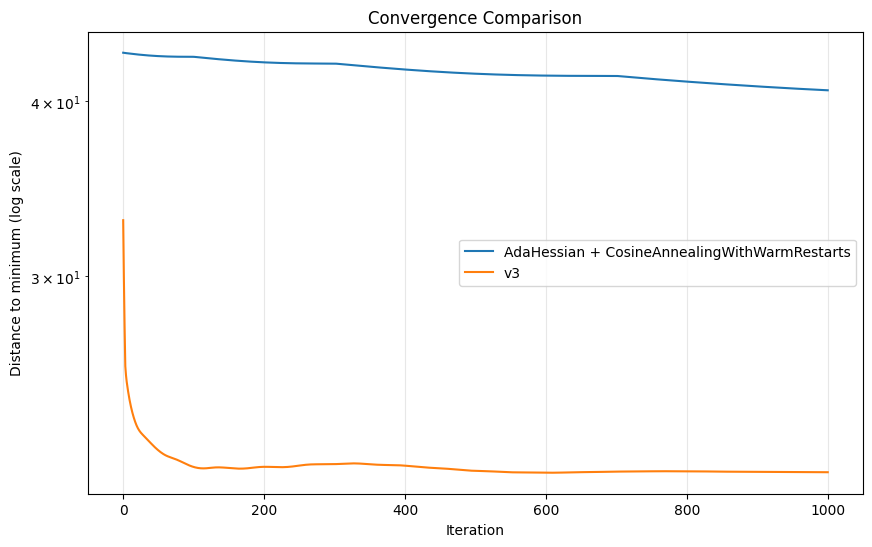

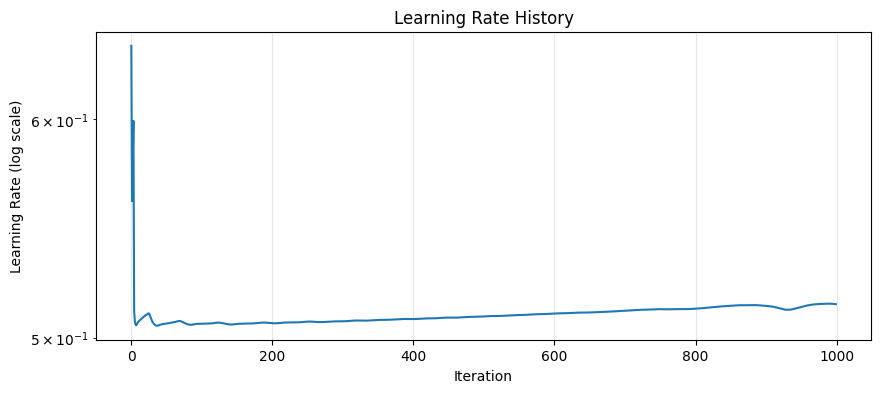

Adam final distance: 4.07e+01
Our optimizer final distance: 2.17e+01
Time Taken for AdaHessian + CosineAnnealingWithWarmRestarts : 3.9952
Time Taken for v3 : 2.3126


In [21]:
x1 = np.random.randn(1000)
terrain = LevyND(1000)
v3_4 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)
callback = CosineAnnealingWithWarmRestarts(
    base_learning_rate = 3e-4,
    minimum_learning_rate = 1e-6,
    restart_after_n_steps=100
)
against_optimizer = AdaHessian(
    function_to_optimize = terrain,
    starting_point=x1,
    scheduler=callback,
    beta_for_momentum=0.999,
    beta_for_velocity=0.99
)
clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_4,
                  against_opt_name="AdaHessian + CosineAnnealingWithWarmRestarts",
                  opt_2_name='v3')

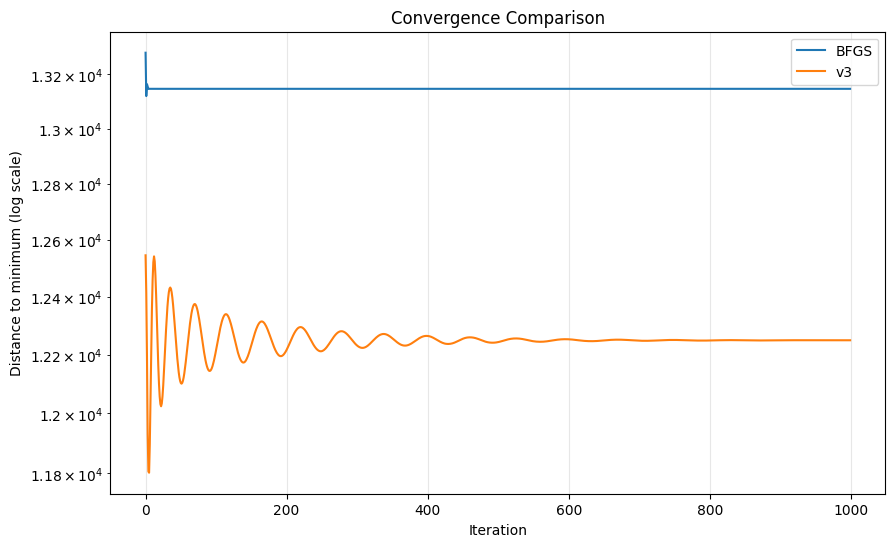

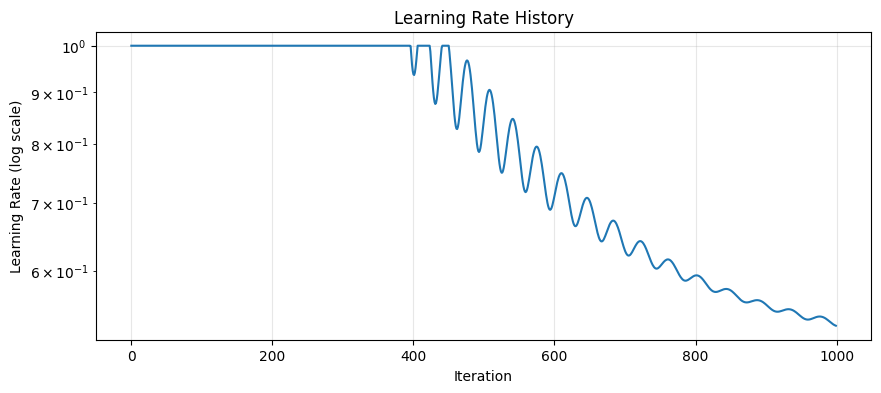

Adam final distance: 1.31e+04
Our optimizer final distance: 1.22e+04
Time Taken for BFGS : 3.4857
Time Taken for v3 : 0.9987


In [22]:
terrain = SchwefelND(1000)

v3_5 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

against_optimizer = BFGS(
    function_to_optimize=terrain,
    starting_point=x1
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_5,
                  against_opt_name="BFGS",
                  opt_2_name='v3')

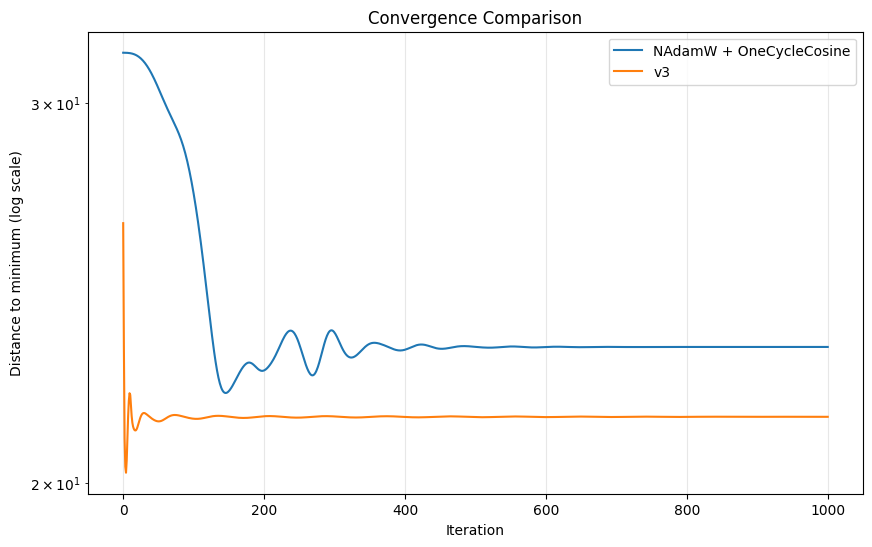

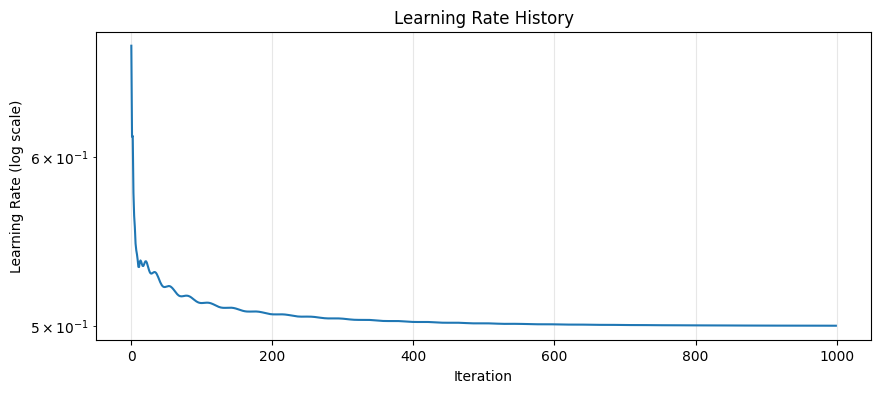

Adam final distance: 2.31e+01
Our optimizer final distance: 2.15e+01
Time Taken for NAdamW + OneCycleCosine : 0.9669
Time Taken for v3 : 1.4248


In [23]:
x1 = np.random.randn(1000)
terrain = AckleyND(1000)
v3_6 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = NAdamW(
    function_to_optimize=terrain,
    beta=0.99,
    alpha=0.999,
    x=x1,
    epsilon=1e-8,
    scheduler=callback,
    regularization_factor = 0.01
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_6,
                  against_opt_name="NAdamW + OneCycleCosine",
                  opt_2_name='v3')

## Convergence speed is way faster for custom optimizer, and way faster than any 2nd degree optimizer

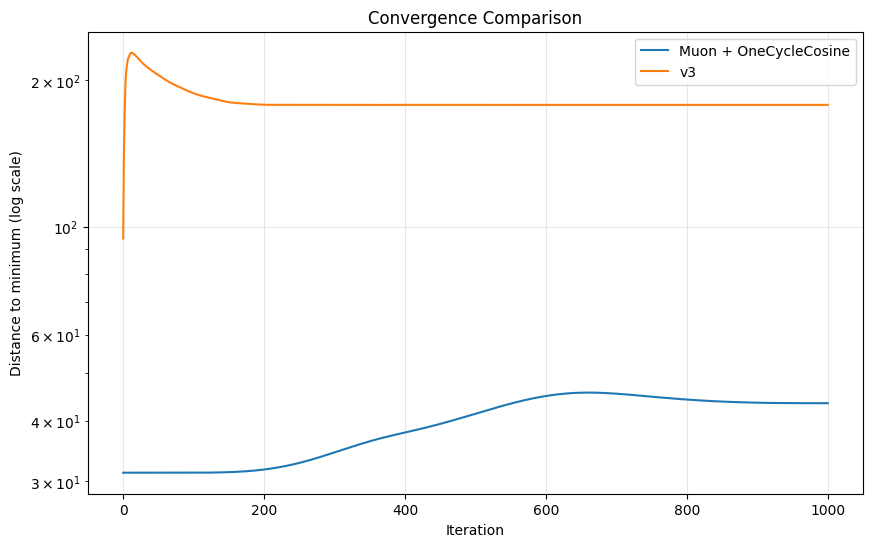

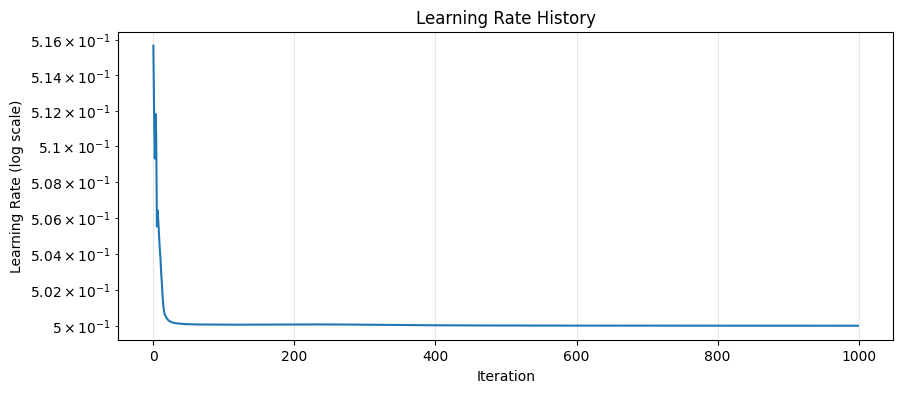

Adam final distance: 4.34e+01
Our optimizer final distance: 1.78e+02
Time Taken for Muon + OneCycleCosine : 0.8566
Time Taken for v3 : 0.9126


In [24]:
x1 = np.random.randn(1000)
terrain = RastriginND(1000)
v3_7 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = Muon(
    function_to_optimize=terrain,
    starting_point=x1,
    iterations_to_estimate_inverse_squareroot=20,
    scheduler=callback,
    beta=0.999
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_7,
                  against_opt_name="Muon + OneCycleCosine",
                  opt_2_name='v3')

# Muon + OneCycleCosine beats us in Rastragrin for some reason but we beat it in all other terrains

# EDIT: mostly all optimizers beat us in Rastragrin, why tho?

observation: the optimizer fails while dealing with sinusodial terrains

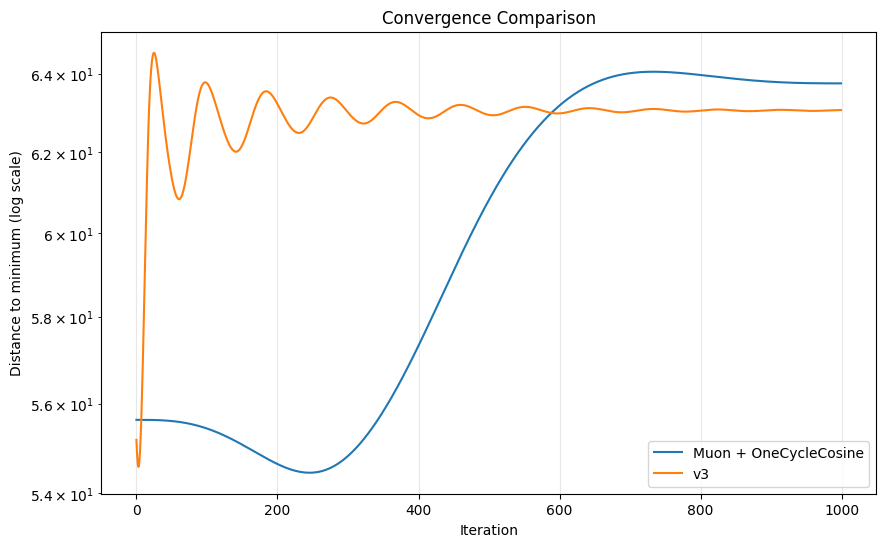

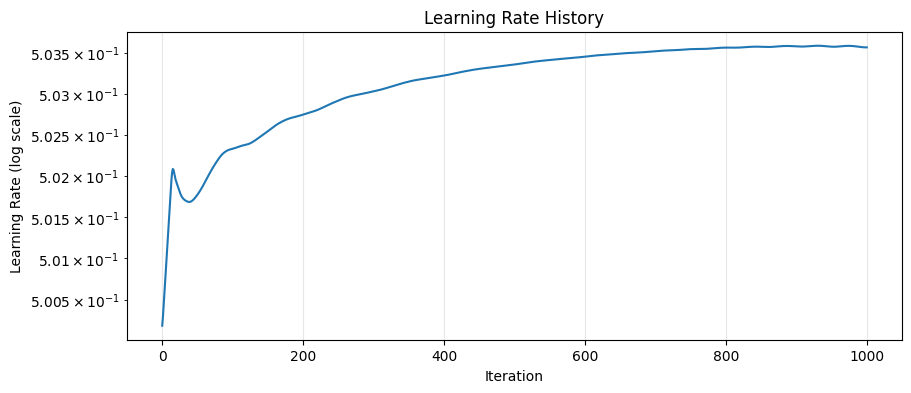

Adam final distance: 6.37e+01
Our optimizer final distance: 6.31e+01
Time Taken for Muon + OneCycleCosine : 0.2514
Time Taken for v3 : 0.2570


In [25]:
x1 = np.random.randn(1000)
terrain = DoubleWellND(1000)
v3_8 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = Muon(
    function_to_optimize=terrain,
    starting_point=x1,
    iterations_to_estimate_inverse_squareroot=20,
    scheduler=callback,
    beta=0.999
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_8,
                  against_opt_name="Muon + OneCycleCosine",
                  opt_2_name='v3')

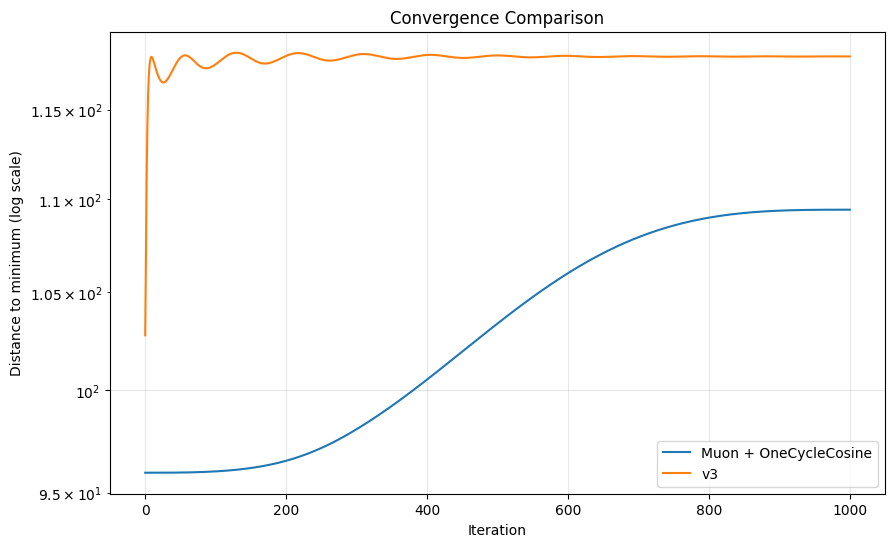

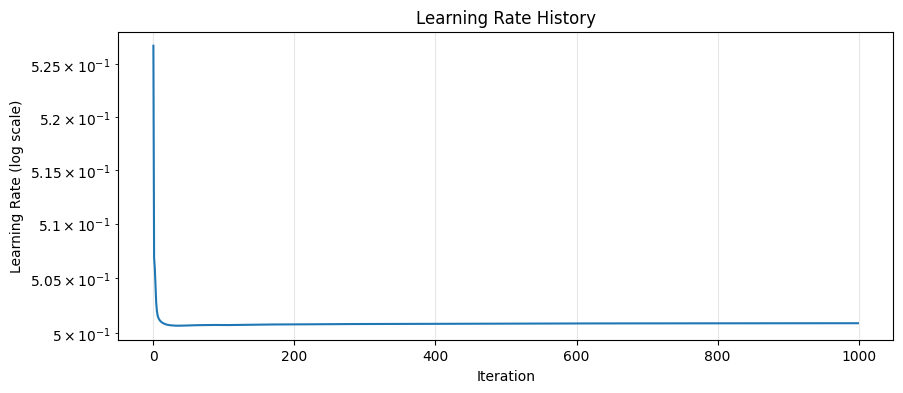

Adam final distance: 1.09e+02
Our optimizer final distance: 1.18e+02
Time Taken for Muon + OneCycleCosine : 0.2611
Time Taken for v3 : 0.3024


In [26]:
x1 = np.random.randn(1000)
terrain = StyblinskiTangND(1000)
v3_9 = CurvatureAndGradientBasedOptimizer_v3(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = Muon(
    function_to_optimize=terrain,
    starting_point=x1,
    iterations_to_estimate_inverse_squareroot=20,
    scheduler=callback,
    beta=0.999
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v3_9,
                  against_opt_name="Muon + OneCycleCosine",
                  opt_2_name='v3')

In [27]:
import numpy as np


class CurvatureAndGradientBasedOptimizer_v4:

    def __init__(
            self,
            function_to_optimize,
            starting_point,
            minimum_learning_rate,
            maximum_learning_rate,
            alpha,
            beta
    ):
        self.fn = function_to_optimize
        self.min_lr = minimum_learning_rate
        self.max_lr = maximum_learning_rate
        self.alpha = alpha
        self.beta = beta
        self.t = 0
        self.x = np.array(starting_point, dtype=float)
        self.g = np.zeros_like(self.x)
        self.g_bar = np.zeros_like(self.x)
        self.g_hat = np.zeros_like(self.x)

        self.kappa_bar = 0.0
        self.kappa_hat = 0.0

        self.kappa_bar_signed = 0.0
        self.kappa_hat_signed = 0.0

        self.history_x = []
        self.history_g_hat = []
        self.history_kappa_hat = []
        self.history_lr = []
        self.history_euclidean_distance_minima_convergence = []

    def calculate_gradients(self):
        return self.fn.gradients(self.x)

    def calculate_hessian_change(self, epsilon=1e-4):
        raw = (self.fn.gradients(self.x + epsilon * self.g) - self.g) / epsilon
        return raw

    def calculate_curvature(self):
        g_norm = np.linalg.norm(self.g)
        if g_norm < 1e-12:
            return 0.0
        g_unit = self.g / g_norm
        return (g_unit.T @ self.calculate_hessian_change()) / (g_unit.T @ g_unit)

    def track_curvature_and_gradient(self):
        self.t += 1
        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * self.g
        kappa = self.calculate_curvature()

        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * kappa ** 2
        self.kappa_bar_signed = self.beta * self.kappa_bar_signed + (1 - self.beta) * kappa

        self.g_hat = self.g_bar / (1 - self.alpha ** self.t)
        self.kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        self.kappa_hat_signed = self.kappa_bar_signed / (1 - self.beta ** self.t)

        return self.kappa_hat, self.g_hat, self.kappa_hat_signed

    def relu(self, x):
        return np.where(x > 0, x, 0)

    def revrelu(self, x):
        return np.where(x < 0, -x, 0)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def learning_rate_positive_curvature(self):
        g_distance = np.linalg.norm(self.g_hat)
        term_1 = 1 / (self.relu(self.kappa_hat) + 1 / g_distance)
        term_2 = (1 - self.sigmoid(self.revrelu(self.kappa_hat * g_distance)))
        lr = (term_1 + term_2)
        return float(np.clip(lr, self.min_lr, self.max_lr))

    def learning_rate_negative_curvature(self):
        g_distance = np.linalg.norm(self.g_hat)
        term_1 = 1 / (self.relu(self.kappa_hat_signed) + 1 / g_distance)
        term_2 = (1 - self.sigmoid(self.revrelu(self.kappa_hat_signed * g_distance)))
        lr = (term_1 + term_2)
        return float(np.clip(lr, self.min_lr, self.max_lr))

    def get_learning_rate(self):
        if self.kappa_hat_signed >= 0:
            eta = self.learning_rate_positive_curvature()
        else:
            eta = self.learning_rate_negative_curvature()
        return eta

    def step(self):
        self.g = self.calculate_gradients()
        kappa_hat, g_hat, kappa_hat2 = self.track_curvature_and_gradient()
        eta = self.get_learning_rate()
        self.x = self.x - eta * g_hat / np.sqrt(self.kappa_hat)

        self.history_x.append(self.x.copy())
        self.history_g_hat.append(g_hat.copy())
        self.history_kappa_hat.append(kappa_hat)
        self.history_lr.append(eta)

        minima = self.fn.minima()
        if minima is not None:
            self.history_euclidean_distance_minima_convergence.append(
                np.linalg.norm(self.x - minima)
            )

        return self.x, eta, kappa_hat, g_hat

    def track_history(self):
        return {
            "x_history": self.history_x,
            "g_hat_history": self.history_g_hat,
            "kappa_hat_history": self.history_kappa_hat,
            "lr_history": self.history_lr,
            "convergence_history": self.history_euclidean_distance_minima_convergence
        }

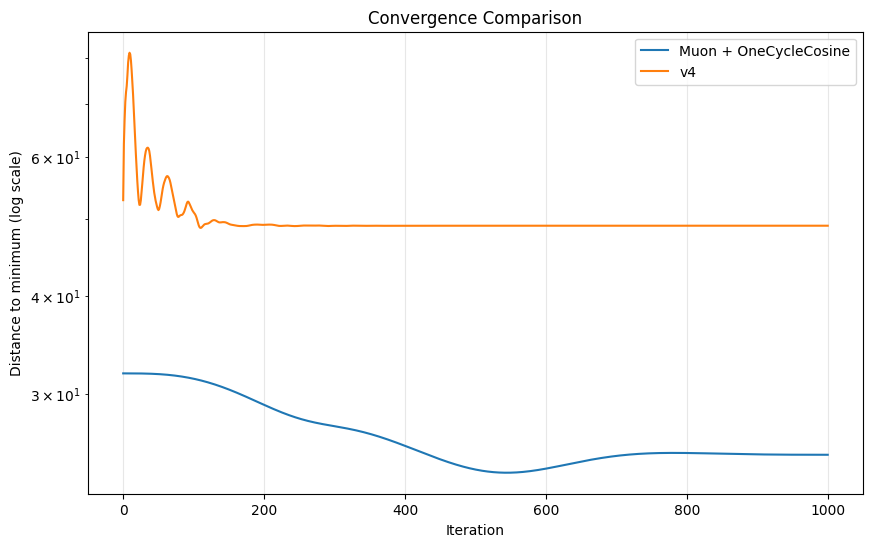

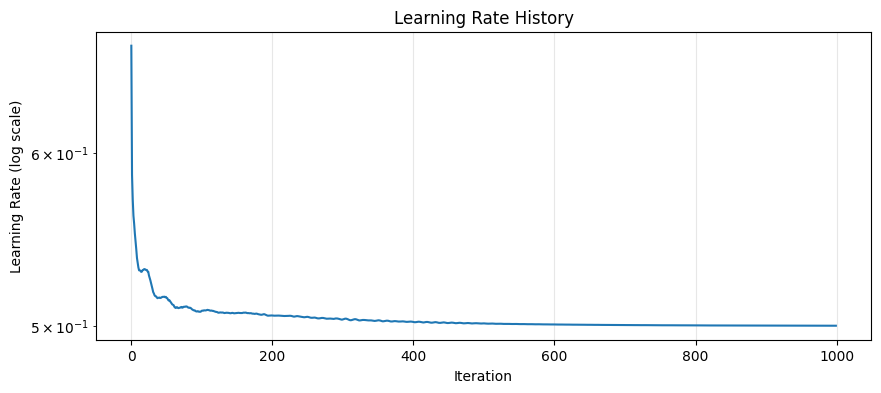

Adam final distance: 2.51e+01
Our optimizer final distance: 4.91e+01
Time Taken for Muon + OneCycleCosine : 1.1601
Time Taken for v4 : 1.2607


In [28]:
x1 = np.random.randn(1000)
terrain = AckleyND(1000)
v4 = CurvatureAndGradientBasedOptimizer_v4(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = Muon(
    function_to_optimize=terrain,
    starting_point=x1,
    iterations_to_estimate_inverse_squareroot=20,
    scheduler=callback,
    beta=0.999
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v4,
                  against_opt_name="Muon + OneCycleCosine",
                  opt_2_name='v4')

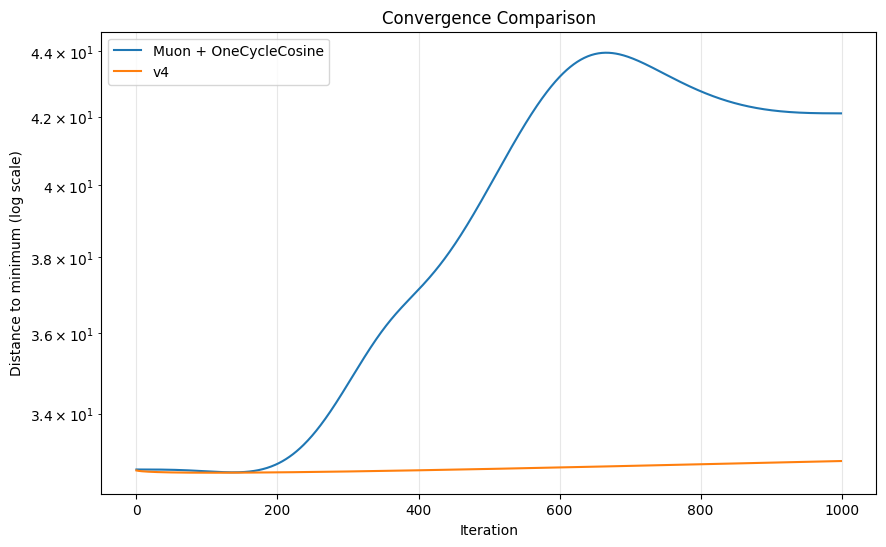

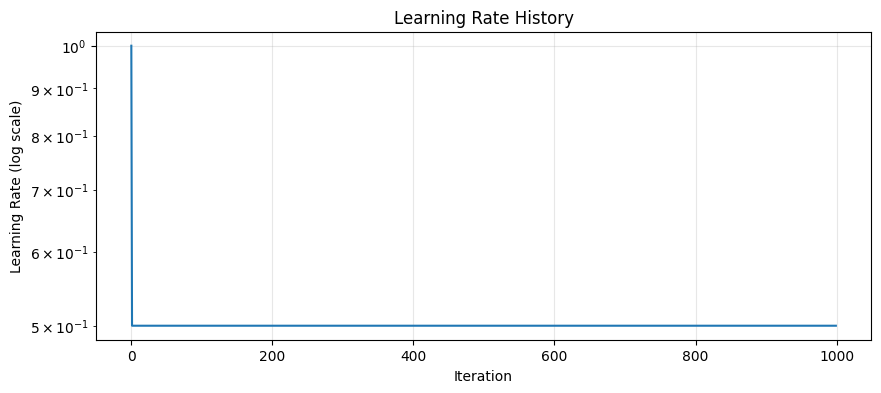

Adam final distance: 4.21e+01
Our optimizer final distance: 3.29e+01
Time Taken for Muon + OneCycleCosine : 0.8576
Time Taken for v4 : 1.1127


In [29]:
x1 = np.random.randn(1000)
terrain = RastriginND(1000)
v4_2 = CurvatureAndGradientBasedOptimizer_v4(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = Muon(
    function_to_optimize=terrain,
    starting_point=x1,
    iterations_to_estimate_inverse_squareroot=20,
    scheduler=callback,
    beta=0.999
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v4_2,
                  against_opt_name="Muon + OneCycleCosine",
                  opt_2_name='v4')

In [30]:
import numpy as np


class CurvatureAndGradientBasedOptimizer_v5:

    def __init__(
            self,
            function_to_optimize,
            starting_point,
            minimum_learning_rate,
            maximum_learning_rate,
            alpha,
            beta
    ):
        self.fn = function_to_optimize
        self.min_lr = minimum_learning_rate
        self.max_lr = maximum_learning_rate
        self.alpha = alpha
        self.beta = beta
        self.t = 0
        self.x = np.array(starting_point, dtype=float)
        self.g = np.zeros_like(self.x)
        self.g_bar = np.zeros_like(self.x)
        self.g_hat = np.zeros_like(self.x)
        self.kappa_bar = 0.0
        self.kappa_hat = 0.0

        self.m = 0.0
        self.m_hat = 0.0
        self.v = 0.0
        self.v_hat = 0.0

        self.history_x = []
        self.history_g_hat = []
        self.history_kappa_hat = []
        self.history_lr = []
        self.history_euclidean_distance_minima_convergence = []

    def calculate_gradients(self):
        return self.fn.gradients(self.x)

    def calculate_hessian_change(self, epsilon=1e-4):
        raw = (self.fn.gradients(self.x + epsilon * self.g/np.linalg.norm(self.g)) - self.g) / epsilon
        return raw

    def calculate_curvature(self):
        g_norm = self.g/np.linalg.norm(self.g)
        denominator = g_norm.T @ g_norm
        return (g_norm.T @ self.calculate_hessian_change()) / denominator

    def track_curvature_and_gradient(self):
        self.t += 1
        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * self.g
        kappa = self.calculate_curvature()
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * kappa ** 2
        self.g_hat = self.g_bar / (1 - self.alpha ** self.t)
        self.kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)

        self.m = self.beta * self.m + (1 - self.beta) * self.g
        self.v = self.alpha * self.v + (1 - self.alpha) * self.g ** 2

        self.m_hat = self.m / (1 - self.beta ** self.t)
        self.v_hat = self.v / (1 - self.alpha ** self.t)

    def relu(self, x):
        return np.where(x > 0, x, 0)
    def revrelu(self, x):
        return np.where(x < 0, -x, 0)
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def get_learning_rate(self):
        g_distance = np.linalg.norm(self.g_hat)
        term_1 = 1 / (self.relu(self.kappa_hat) + 1 / g_distance)
        term_2 = (1 - self.sigmoid(self.revrelu(self.kappa_hat * g_distance)))
        lr = (term_1 + term_2)
        return float(np.clip(lr, self.min_lr, self.max_lr))

    def step(self):
        self.g = self.calculate_gradients()
        self.track_curvature_and_gradient()
        eta = self.get_learning_rate()
        self.x = self.x - eta * self.m_hat / (np.sqrt(self.v_hat) + self.kappa_hat ** 0.025)

        self.history_x.append(self.x.copy())
        self.history_g_hat.append(self.g_hat.copy())
        self.history_kappa_hat.append(self.kappa_hat)
        self.history_lr.append(eta)

        minima = self.fn.minima()
        if minima is not None:
            self.history_euclidean_distance_minima_convergence.append(
                np.linalg.norm(self.x - minima)
            )

        return self.x, eta, self.kappa_hat, self.g_hat

    def track_history(self):
        return {
            "x_history": self.history_x,
            "g_hat_history": self.history_g_hat,
            "kappa_hat_history": self.history_kappa_hat,
            "lr_history": self.history_lr,
            "convergence_history": self.history_euclidean_distance_minima_convergence
        }

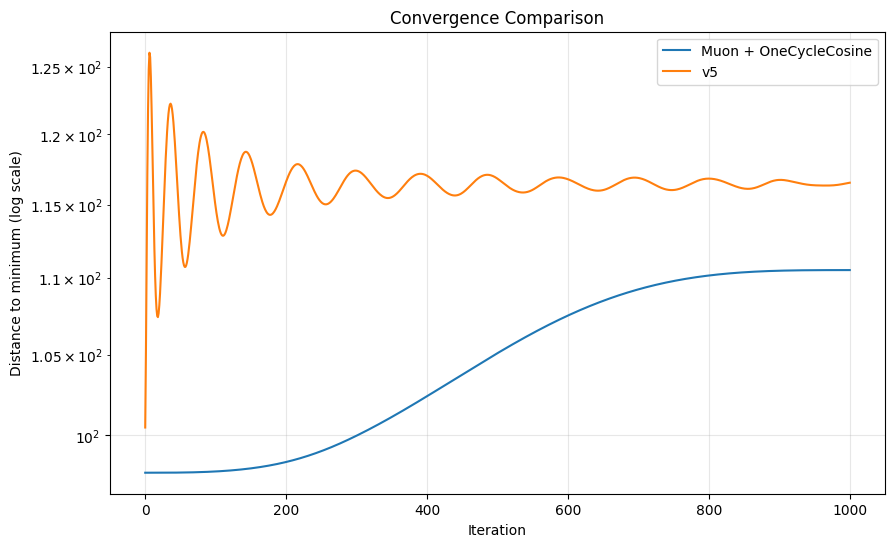

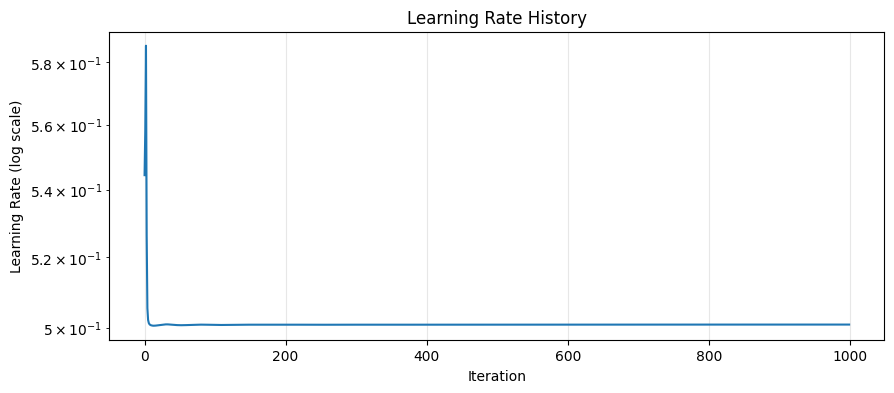

Adam final distance: 1.11e+02
Our optimizer final distance: 1.17e+02
Time Taken for Muon + OneCycleCosine : 0.2754
Time Taken for v5 : 0.4223


In [31]:
x1 = np.random.randn(1000)
terrain = StyblinskiTangND(1000)
v5 = CurvatureAndGradientBasedOptimizer_v5(
    function_to_optimize=terrain,
    starting_point=x1,
    minimum_learning_rate=1e-10,
    maximum_learning_rate=1,
    alpha=0.99,
    beta=0.999
)

callback = OneCycleCosine(
    total_steps=1000,
    minimum_learning_rate=1e-5,
    maximum_learning_rate=1e-1,
    final_learning_rate=1e-4,
    # total_steps=1000
)

against_optimizer = Muon(
    function_to_optimize=terrain,
    starting_point=x1,
    iterations_to_estimate_inverse_squareroot=20,
    scheduler=callback,
    beta=0.999
)

clock_experiments(against_optimizer=against_optimizer,
                  optimizer_2=v5,
                  against_opt_name="Muon + OneCycleCosine",
                  opt_2_name='v5')

# ON DATASETS

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import copy

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MNISTCNN(nn.Module):
    def __init__(self):
        super(MNISTCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


class PyTorchCurvatureOptimizer:
    def __init__(self, model, criterion, min_lr=1e-4, max_lr=1e-2, alpha=0.9, beta=0.999, epsilon=1e-4):
        self.model = model
        self.criterion = criterion
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.alpha = alpha
        self.beta = beta
        self.epsilon = epsilon
        self.t = 0

        self.params = [p for p in model.parameters() if p.requires_grad]

        total_params = sum(p.numel() for p in self.params)
        self.g_bar = torch.zeros(total_params, device=device)
        self.kappa_bar = torch.zeros(1, device=device)

    def _get_flat_grads(self, x, y):
        self.model.zero_grad()
        out = self.model(x)
        loss = self.criterion(out, y)
        loss.backward()
        return torch.cat([p.grad.view(-1) for p in self.params]), loss.item()

    def _get_flat_params(self):
        return torch.cat([p.data.view(-1) for p in self.params])

    def _set_flat_params(self, flat_tensor):
        offset = 0
        for p in self.params:
            numel = p.numel()
            p.data.copy_(flat_tensor[offset:offset + numel].view_as(p.data))
            offset += numel

    def step(self, x, y):
        self.t += 1

        g, loss_val = self._get_flat_grads(x, y)
        g_norm_val = torch.linalg.norm(g) + 1e-8
        g_unit = g / g_norm_val

        original_params = self._get_flat_params()

        perturbed_params = original_params + self.epsilon * g_unit
        self._set_flat_params(perturbed_params)

        g_perturbed, _ = self._get_flat_grads(x, y)

        self._set_flat_params(original_params)

        hessian_change = (g_perturbed - g) / self.epsilon
        kappa = torch.dot(g_unit, hessian_change) / torch.dot(g_unit, g_unit)

        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * g
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * (kappa) #** 2)

        g_hat = self.g_bar / (1 - self.alpha ** self.t)
        kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        kappa_hat = torch.clamp(kappa_hat, min=1e-8)

        g_distance = torch.linalg.norm(g_hat) + 1e-8

        relu_kappa = torch.clamp(kappa_hat, min=0)
        revrelu_kappa = torch.clamp(-kappa_hat, min=0)

        term_1 = 1.0 / (relu_kappa + 1.0 / g_distance)
        term_2 = torch.sigmoid(revrelu_kappa * g_distance) # 1-

        lr = term_1 + term_2
        eta = torch.clamp(lr, self.min_lr, self.max_lr)

        new_params = original_params - eta * g_hat # / torch.sqrt(kappa_hat)
        self._set_flat_params(new_params)

        return loss_val


def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return 100. * correct / len(loader.dataset)


epochs = 3

print("=== 1. Running Baseline: Adam + Cosine Annealing ===")
model_adam = MNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=1e-3)
scheduler_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=epochs)

for epoch in range(1, epochs + 1):
    model_adam.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer_adam.zero_grad()
        output = model_adam(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer_adam.step()
        total_loss += loss.item()

    scheduler_adam.step()
    accuracy = evaluate(model_adam, test_loader)
    print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_loader):.4f} | Test Acc: {accuracy:.2f}%")

print("\n")
print("=== 2. Running Custom Curvature-Based Optimizer ===")
model_custom = MNISTCNN().to(device)
optimizer_custom = PyTorchCurvatureOptimizer(
    model=model_custom,
    criterion=criterion,
    min_lr=1e-10,
    max_lr=1,
    alpha=0.99,
    beta=0.999
)

for epoch in range(1, epochs + 1):
    model_custom.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        loss_val = optimizer_custom.step(data, target)
        total_loss += loss_val

    accuracy = evaluate(model_custom, test_loader)
    print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_loader):.4f} | Test Acc: {accuracy:.2f}%")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 441kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.99MB/s]


=== 1. Running Baseline: Adam + Cosine Annealing ===
Epoch 1 | Avg Loss: 0.1698 | Test Acc: 98.11%
Epoch 2 | Avg Loss: 0.0493 | Test Acc: 98.78%
Epoch 3 | Avg Loss: 0.0272 | Test Acc: 98.87%


=== 2. Running Custom Curvature-Based Optimizer ===
Epoch 1 | Avg Loss: 0.2045 | Test Acc: 97.25%
Epoch 2 | Avg Loss: 0.0665 | Test Acc: 98.19%
Epoch 3 | Avg Loss: 0.0574 | Test Acc: 97.97%


The above version of the optimizer dosent work that well with our pre-defined terrains but works as good as adam on complex terrains, im not sure why. Anyways the dataset on which the optimizer was tested is really simple, the optimzer underperforms on CIFAR10 dataset

The optimizer actually converges so the entire idea wasent a fail

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import copy

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CIFAR10CNN(nn.Module):
    def __init__(self):
        super(CIFAR10CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Downloading CIFAR10 instead of MNIST
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


class PyTorchCurvatureOptimizer:
    def __init__(self, model, criterion, min_lr=1e-10, max_lr=1, alpha=0.99, beta=0.999, epsilon=1e-4):
        self.model = model
        self.criterion = criterion
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.alpha = alpha
        self.beta = beta
        self.epsilon = epsilon
        self.t = 0

        self.params = [p for p in model.parameters() if p.requires_grad]

        total_params = sum(p.numel() for p in self.params)
        self.g_bar = torch.zeros(total_params, device=device)
        self.kappa_bar = torch.zeros(1, device=device)

    def _get_flat_grads(self, x, y):
        self.model.zero_grad()
        out = self.model(x)
        loss = self.criterion(out, y)
        loss.backward()
        return torch.cat([p.grad.view(-1) for p in self.params]), loss.item()

    def _get_flat_params(self):
        return torch.cat([p.data.view(-1) for p in self.params])

    def _set_flat_params(self, flat_tensor):
        offset = 0
        for p in self.params:
            numel = p.numel()
            p.data.copy_(flat_tensor[offset:offset + numel].view_as(p.data))
            offset += numel

    def step(self, x, y):
        self.t += 1

        g, loss_val = self._get_flat_grads(x, y)
        g_norm_val = torch.linalg.norm(g) + 1e-8
        g_unit = g / g_norm_val

        original_params = self._get_flat_params()

        perturbed_params = original_params + self.epsilon * g_unit
        self._set_flat_params(perturbed_params)

        g_perturbed, _ = self._get_flat_grads(x, y)

        self._set_flat_params(original_params)

        hessian_change = (g_perturbed - g) / self.epsilon
        kappa = torch.dot(g_unit, hessian_change) / torch.dot(g_unit, g_unit)

        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * g
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * (kappa)

        g_hat = self.g_bar / (1 - self.alpha ** self.t)
        kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        kappa_hat = torch.clamp(kappa_hat, min=1e-8)

        g_distance = torch.linalg.norm(g_hat) + 1e-8

        relu_kappa = torch.clamp(kappa_hat, min=0)
        revrelu_kappa = torch.clamp(-kappa_hat, min=0)

        term_1 = 1.0 / (relu_kappa + 1.0 / g_distance)
        term_2 = torch.sigmoid(revrelu_kappa * g_distance)

        lr = term_1 + term_2
        eta = torch.clamp(lr, self.min_lr, self.max_lr)

        new_params = original_params - eta * g_hat
        self._set_flat_params(new_params)

        return loss_val


def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return 100. * correct / len(loader.dataset)


# --- 4. EXECUTION LOOP ---
epochs = 3
criterion = nn.CrossEntropyLoss()

print("=== 1. Running Baseline: Adam + Cosine Annealing ===")
model_adam = CIFAR10CNN().to(device)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=1e-3)
scheduler_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=epochs)

for epoch in range(1, epochs + 1):
    model_adam.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.squeeze().to(device) # squeeze target if dimensions mismatch
        optimizer_adam.zero_grad()
        output = model_adam(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer_adam.step()
        total_loss += loss.item()

    scheduler_adam.step()
    accuracy = evaluate(model_adam, test_loader)
    print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_loader):.4f} | Test Acc: {accuracy:.2f}%")

print("\n")
print("=== 2. Running Custom Curvature-Based Optimizer ===")
model_custom = CIFAR10CNN().to(device)
optimizer_custom = PyTorchCurvatureOptimizer(
    model=model_custom,
    criterion=criterion,
    min_lr=1e-10,
    max_lr=1,
    alpha=0.99,
    beta=0.999
)

for epoch in range(1, epochs + 1):
    model_custom.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        loss_val = optimizer_custom.step(data, target)
        total_loss += loss_val

    accuracy = evaluate(model_custom, test_loader)
    print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_loader):.4f} | Test Acc: {accuracy:.2f}%")

100%|██████████| 170M/170M [28:51<00:00, 98.5kB/s]


=== 1. Running Baseline: Adam + Cosine Annealing ===
Epoch 1 | Avg Loss: 1.3687 | Test Acc: 58.55%
Epoch 2 | Avg Loss: 1.0402 | Test Acc: 63.66%
Epoch 3 | Avg Loss: 0.8796 | Test Acc: 66.03%


=== 2. Running Custom Curvature-Based Optimizer ===
Epoch 1 | Avg Loss: 1.7602 | Test Acc: 41.94%
Epoch 2 | Avg Loss: 1.5701 | Test Acc: 44.75%
Epoch 3 | Avg Loss: 1.4617 | Test Acc: 47.92%


In [ ]:
class PyTorchCurvatureOptimizer:
    def __init__(self, model, criterion, min_lr=1e-10, max_lr=1, alpha=0.99, beta=0.999, epsilon=1e-4):
        self.model = model
        self.criterion = criterion
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.alpha = alpha
        self.beta = beta
        self.epsilon = epsilon
        self.t = 0

        self.params = [p for p in model.parameters() if p.requires_grad]

        total_params = sum(p.numel() for p in self.params)
        self.g_bar = torch.zeros(total_params, device=device)
        self.kappa_bar = torch.zeros(1, device=device)

    def _get_flat_grads(self, x, y):
        self.model.zero_grad()
        out = self.model(x)
        loss = self.criterion(out, y)
        loss.backward()
        return torch.cat([p.grad.view(-1) for p in self.params]), loss.item()

    def _get_flat_params(self):
        return torch.cat([p.data.view(-1) for p in self.params])

    def _set_flat_params(self, flat_tensor):
        offset = 0
        for p in self.params:
            numel = p.numel()
            p.data.copy_(flat_tensor[offset:offset + numel].view_as(p.data))
            offset += numel

    def step(self, x, y):
        self.t += 1

        g, loss_val = self._get_flat_grads(x, y)
        g_norm_val = torch.linalg.norm(g) + 1e-8
        g_unit = g / g_norm_val

        original_params = self._get_flat_params()

        perturbed_params = original_params + self.epsilon * g_unit
        self._set_flat_params(perturbed_params)

        g_perturbed, _ = self._get_flat_grads(x, y)

        self._set_flat_params(original_params)

        hessian_change = (g_perturbed - g) / self.epsilon
        kappa = torch.dot(g_unit, hessian_change) / torch.dot(g_unit, g_unit)

        self.g_bar = self.alpha * self.g_bar + (1 - self.alpha) * g
        self.kappa_bar = self.beta * self.kappa_bar + (1 - self.beta) * (kappa) ** 2

        g_hat = self.g_bar / (1 - self.alpha ** self.t)
        kappa_hat = self.kappa_bar / (1 - self.beta ** self.t)
        kappa_hat = torch.clamp(kappa_hat, min=1e-8)

        g_distance = torch.linalg.norm(g_hat) + 1e-8

        relu_kappa = torch.clamp(kappa_hat, min=0)
        revrelu_kappa = torch.clamp(-kappa_hat, min=0)

        term_1 = 1.0 / (relu_kappa + 1.0 / g_distance)
        term_2 = torch.sigmoid(revrelu_kappa * g_distance)

        lr = term_1 + term_2
        eta = torch.clamp(lr, self.min_lr, self.max_lr)

        new_params = original_params - eta * g_hat / torch.sqrt(kappa_hat)
        self._set_flat_params(new_params)

        return loss_val


def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return 100. * correct / len(loader.dataset)


epochs = 3
criterion = nn.CrossEntropyLoss()

print("=== 1. Running Baseline: Adam + Cosine Annealing ===")
model_adam = CIFAR10CNN().to(device)  # Swapped to CIFAR10 model
optimizer_adam = optim.Adam(model_adam.parameters(), lr=1e-3)
scheduler_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=epochs)

for epoch in range(1, epochs + 1):
    model_adam.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.squeeze().to(device) # squeeze target if dimensions mismatch
        optimizer_adam.zero_grad()
        output = model_adam(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer_adam.step()
        total_loss += loss.item()

    scheduler_adam.step()
    accuracy = evaluate(model_adam, test_loader)
    print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_loader):.4f} | Test Acc: {accuracy:.2f}%")

print("\n")
print("=== 2. Running Custom Curvature-Based Optimizer ===")
model_custom = CIFAR10CNN().to(device)
optimizer_custom = PyTorchCurvatureOptimizer(
    model=model_custom,
    criterion=criterion,
    min_lr=1e-10,
    max_lr=1,
    alpha=0.99,
    beta=0.999
)

for epoch in range(1, epochs + 1):
    model_custom.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        loss_val = optimizer_custom.step(data, target)
        total_loss += loss_val

    accuracy = evaluate(model_custom, test_loader)
    print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_loader):.4f} | Test Acc: {accuracy:.2f}%")

=== 1. Running Baseline: Adam + Cosine Annealing ===
Epoch 1 | Avg Loss: 1.3564 | Test Acc: 59.92%
Epoch 2 | Avg Loss: 1.0057 | Test Acc: 66.01%
Epoch 3 | Avg Loss: 0.8448 | Test Acc: 68.19%


=== 2. Running Custom Curvature-Based Optimizer ===
Epoch 1 | Avg Loss: 1.6450 | Test Acc: 50.22%
Epoch 2 | Avg Loss: 1.3169 | Test Acc: 54.48%
Epoch 3 | Avg Loss: 1.1996 | Test Acc: 57.85%
